<a href="https://colab.research.google.com/github/gmauricio-toledo/tda/blob/main/notebooks/Sesi%C3%B3nPr%C3%A1ctica-4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Homología Persistente y series de tiempo</h1>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Un electrocardiograma (ECG) es una prueba sencilla que permite comprobar el ritmo y la actividad eléctrica del corazón. El electrocardiograma registra las señales eléctricas del corazón y se usa para detectar con rapidez problemas cardíacos y controlar la salud del corazón.

El conjunto de datos original de "ECG5000" es un ECG de 20 horas de duración. A continuación, se seleccionaron aleatoriamente 5,000 latidos, cada uno con el mismo número de datos. El paciente tiene una insuficiencia cardíaca congestiva grave y los valores de clase se obtuvieron mediante una anotación automática.

[Fuente del dataset](http://www.timeseriesclassification.com/description.php?Dataset=ECG5000)

In [8]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/DCDPUAEM/DCDP/main/04%20Deep%20Learning/data/ecg.csv"
df = pd.read_csv(url, sep=',',index_col=0)
df

,c0,c1,c2,c3,c4,c5,c6,c7,c8,c9,...,c131,c132,c133,c134,c135,c136,c137,c138,c139,c140
0,1.0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,...,0.160348,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137
1,1.0,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,...,0.560327,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250
2,1.0,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,...,1.284825,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797
3,1.0,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,...,0.491173,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564
4,1.0,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,...,0.966606,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4.0,-1.122969,-2.252925,-2.867628,-3.358605,-3.167849,-2.638360,-1.664162,-0.935655,-0.866953,...,0.205543,-0.472419,-1.310147,-2.029521,-3.221294,-4.176790,-4.009720,-2.874136,-2.008369,-1.808334
4996,2.0,-0.547705,-1.889545,-2.839779,-3.457912,-3.929149,-3.966026,-3.492560,-2.695270,-1.849691,...,1.218185,1.258419,1.907530,2.280888,1.895242,1.437702,1.193433,1.261335,1.150449,0.804932
4997,2.0,-1.351779,-2.209006,-2.520225,-3.061475,-3.065141,-3.030739,-2.622720,-2.044092,-1.295874,...,-0.896575,-1.512234,-2.076075,-2.586042,-3.322799,-3.627311,-3.437038,-2.260023,-1.577823,-0.684531
4998,2.0,-1.124432,-1.905039,-2.192707,-2.904320,-2.900722,-2.761252,-2.569705,-2.043893,-1.490538,...,-2.495989,-2.821782,-3.268355,-3.634981,-3.168765,-2.245878,-1.262260,-0.443307,-0.559769,0.108568


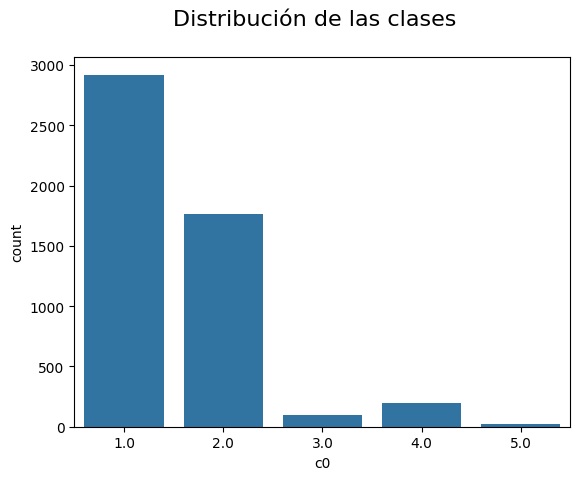

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
plt.suptitle("Distribución de las clases",fontsize=16)
sns.countplot(x='c0', data=df)
plt.show()

In [10]:
df['class'] = df['c0'].apply(lambda x: 1 if x > 1 else 0)
df = df.drop('c0', axis=1)
df

,c1,c2,c3,c4,c5,c6,c7,c8,c9,c10,...,c132,c133,c134,c135,c136,c137,c138,c139,c140,class
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137,0
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,0
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,0
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,0
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,-1.122969,-2.252925,-2.867628,-3.358605,-3.167849,-2.638360,-1.664162,-0.935655,-0.866953,-0.645363,...,-0.472419,-1.310147,-2.029521,-3.221294,-4.176790,-4.009720,-2.874136,-2.008369,-1.808334,1
4996,-0.547705,-1.889545,-2.839779,-3.457912,-3.929149,-3.966026,-3.492560,-2.695270,-1.849691,-1.374321,...,1.258419,1.907530,2.280888,1.895242,1.437702,1.193433,1.261335,1.150449,0.804932,1
4997,-1.351779,-2.209006,-2.520225,-3.061475,-3.065141,-3.030739,-2.622720,-2.044092,-1.295874,-0.733839,...,-1.512234,-2.076075,-2.586042,-3.322799,-3.627311,-3.437038,-2.260023,-1.577823,-0.684531,1
4998,-1.124432,-1.905039,-2.192707,-2.904320,-2.900722,-2.761252,-2.569705,-2.043893,-1.490538,-0.938473,...,-2.821782,-3.268355,-3.634981,-3.168765,-2.245878,-1.262260,-0.443307,-0.559769,0.108568,1


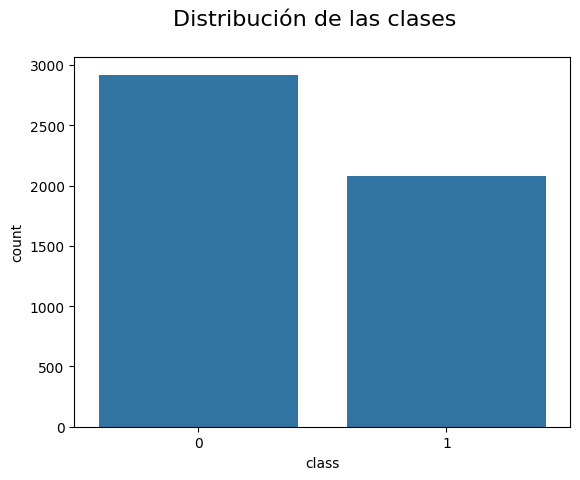

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
plt.suptitle("Distribución de las clases",fontsize=16)
sns.countplot(x='class', data=df)
plt.show()

Dividimos en entrenamiento y prueba.

In [13]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(df.values[:,:-1],
                                                    df['class'].values,
                                                    stratify= df['class'].values,
                                                    test_size=0.2,
                                                    random_state=111)

print(x_train.shape)
print(x_test.shape)

(4000, 140)
(1000, 140)


Re-escalamos al intervalo [0,1]. **Es opcional dejar ejecutar este paso**

In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_scaled = scaler.fit(x_train)
train_data_scaled = data_scaled.transform(x_train)
test_data_scaled = data_scaled.transform(x_test)

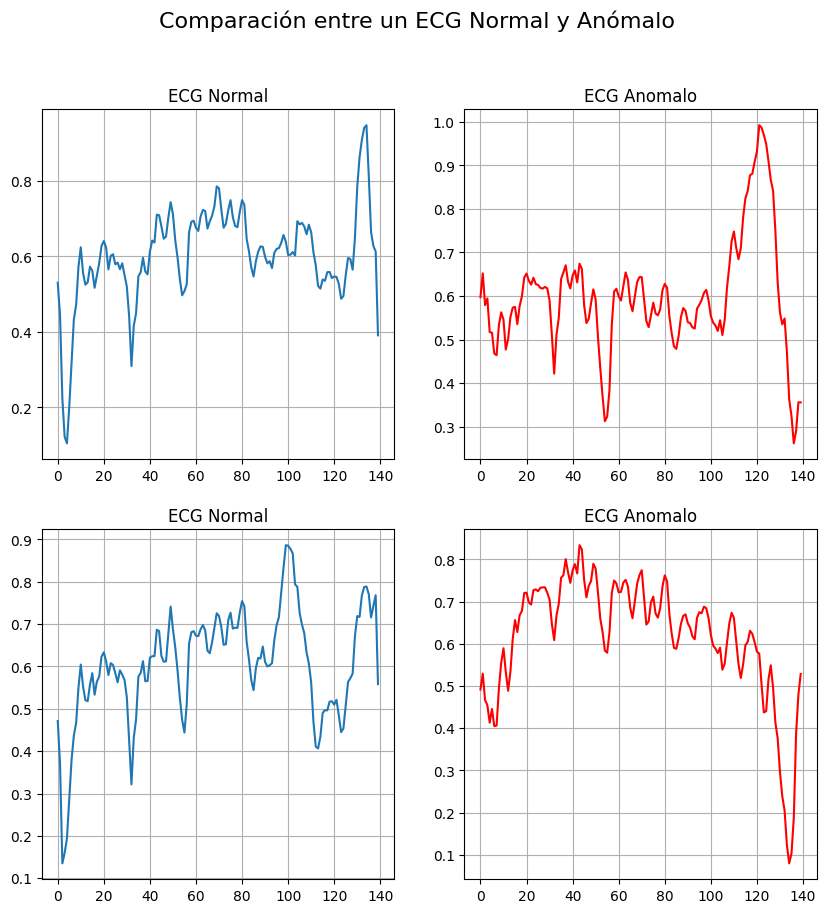

In [17]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 10))
plt.suptitle("Comparación entre un ECG Normal y Anómalo",fontsize=16)
plt.subplot(2, 2, 1)
plt.grid()
plt.plot(np.arange(140), train_data_scaled[y_train==0][0])
plt.title("ECG Normal")
plt.subplot(2, 2, 2)
plt.grid()
plt.plot(np.arange(140), train_data_scaled[y_train==1][0],color='red')
plt.title("ECG Anomalo")
plt.subplot(2, 2, 3)
plt.grid()
plt.plot(np.arange(140), train_data_scaled[y_train==0][1])
plt.title("ECG Normal")
plt.subplot(2, 2, 4)
plt.grid()
plt.plot(np.arange(140), train_data_scaled[y_train==1][1],color='red')
plt.title("ECG Anomalo")
plt.show()

Implementa un clasificador usando Homología Persistente para predecir si un latido es normal o anomalo. Mide el desempeño de tu clasificador usando [`f1_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html).

Usar la clase [TakensEmbedding](https://giotto-ai.github.io/gtda-docs/latest/modules/generated/time_series/embedding/gtda.time_series.TakensEmbedding.html) de giotto-tda para obtener los embeddings de Takens. Usa valores diferentes a los default para inicializar la clase.